In [68]:
import pandas as pd

## Loading the ratings data, movie data and user data


In [73]:
# parsing the data from the u.data file, info about the structure of the data can be found in teh MovieLens README
ratings = pd.read_csv("../data/raw/u.data", sep="\t", names = ["user_id", "item_id", "rating", "timestamp"], encoding="latin_1") 
ratings.head()

,user_id,item_id,rating,timestamp
0,196,242,3,881250949
1,186,302,3,891717742
2,22,377,1,878887116
3,244,51,2,880606923
4,166,346,1,886397596


In [75]:
# parsing user data from u.user
users = pd.read_csv("../data/raw/u.user", sep="|", names = ["user_id", "age", "gender", "occupation", "zip_code"], encoding="latin_1")
users.head()

,user_id,age,gender,occupation,zip_code
0,1,24,M,technician,85711
1,2,53,F,other,94043
2,3,23,M,writer,32067
3,4,24,M,technician,43537
4,5,33,F,other,15213


In [76]:
# parsing movie data from u.item
item_cols = ["item_id", "movie_title", "release_date", "video_release_date", "imdb_url"] + [f"genre_{i}" for i in range(19)]

movies = pd.read_csv("../data/raw/u.item", sep="|", names = item_cols, encoding="latin_1")
movies.head()

,item_id,movie_title,release_date,video_release_date,imdb_url,genre_0,genre_1,genre_2,genre_3,genre_4,...,genre_9,genre_10,genre_11,genre_12,genre_13,genre_14,genre_15,genre_16,genre_17,genre_18
0,1,Toy Story (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Toy%20Story%2...,0,0,0,1,1,...,0,0,0,0,0,0,0,0,0,0
1,2,GoldenEye (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?GoldenEye%20(...,0,1,1,0,0,...,0,0,0,0,0,0,0,1,0,0
2,3,Four Rooms (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Four%20Rooms%...,0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,4,Get Shorty (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Get%20Shorty%...,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,5,Copycat (1995),01-Jan-1995,NaN,http://us.imdb.com/M/title-exact?Copycat%20(1995),0,0,0,0,0,...,0,0,0,0,0,0,0,1,0,0


## Checking distribution and null values


In [77]:
# check the distribution of ratings for the ratings data
import matplotlib.pyplot as plt

<Axes: ylabel='Frequency'>

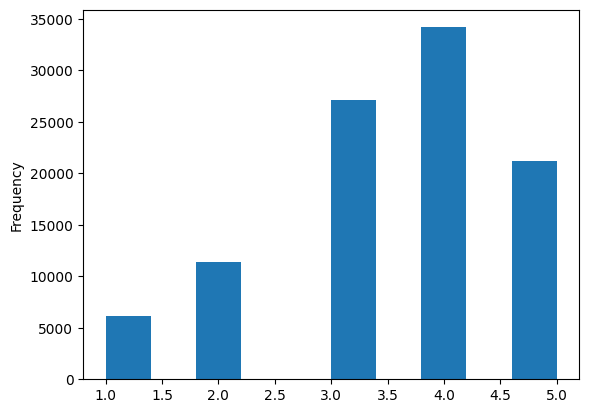

In [78]:
ratings["rating"].plot.hist()

In [79]:
ratings["rating"].value_counts(normalize=True).sort_index()

rating
1    0.06110
2    0.11370
3    0.27145
4    0.34174
5    0.21201
Name: proportion, dtype: float64

The distribution of the ratings shows us that the majority of ratings are between 3 - 4, so we will keep our CTR feature as a 'click' for ratings above 4, i.e a rating of 5.

## Creating the training and test dataset

Here we see the percentage of clicks is 21.2% which is still marginally higher than normal real life rates which range from 2% - 10%, however this will work for the purposes of the simulation.

In [80]:
import numpy as np
import sklearn.model_selection as ml


In [81]:
# combine the ratings, movies and users to create dataframe with all features
features = ratings.merge(movies, on='item_id').merge(users, on='user_id')
features['click'] = (features['rating'] >= 5).astype(int)

click
0    0.78799
1    0.21201
Name: proportion, dtype: float64

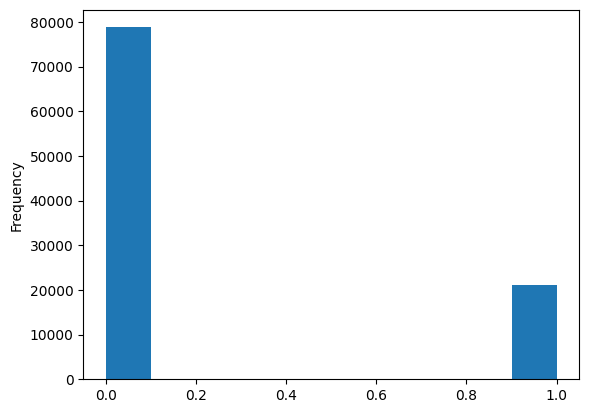

In [82]:
# check the distribution of clicks for the dataset
features["click"].plot.hist()
features["click"].value_counts(normalize=True).sort_index()

In [83]:
features.head()

,user_id,item_id,rating,timestamp,movie_title,release_date,video_release_date,imdb_url,genre_0,genre_1,...,genre_14,genre_15,genre_16,genre_17,genre_18,age,gender,occupation,zip_code,click
0,196,242,3,881250949,Kolya (1996),24-Jan-1997,NaN,http://us.imdb.com/M/title-exact?Kolya%20(1996),0,0,...,0,0,0,0,0,49,M,writer,55105,0
1,186,302,3,891717742,L.A. Confidential (1997),01-Jan-1997,NaN,http://us.imdb.com/M/title-exact?L%2EA%2E+Conf...,0,0,...,0,0,1,0,0,39,F,executive,00000,0
2,22,377,1,878887116,Heavyweights (1994),01-Jan-1994,NaN,http://us.imdb.com/M/title-exact?Heavyweights%...,0,0,...,0,0,0,0,0,25,M,writer,40206,0
3,244,51,2,880606923,Legends of the Fall (1994),01-Jan-1994,NaN,http://us.imdb.com/M/title-exact?Legends%20of%...,0,0,...,1,0,0,1,1,28,M,technician,80525,0
4,166,346,1,886397596,Jackie Brown (1997),01-Jan-1997,NaN,http://us.imdb.com/M/title-exact?imdb-title-11...,0,0,...,0,0,0,0,0,47,M,educator,55113,0


In [84]:
# save the features dataframe to be used in the other notebook
features.to_parquet("../data/processed/features.parquet")

In [86]:
# create user-item matrix to see sparsity

user_item_matrix = features.pivot_table(index='user_id', columns='item_id', values='rating')
print(user_item_matrix.shape)
user_item_matrix.head()

(943, 1682)


item_id,1,2,3,4,5,6,7,8,9,10,...,1673,1674,1675,1676,1677,1678,1679,1680,1681,1682
user_id,,,,,,,,,,,,,,,,,,,,,
1,5.0,3.0,4.0,3.0,3.0,5.0,4.0,1.0,5.0,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,4.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [89]:
# check the sparsity in numbers
users, items = user_item_matrix.shape

no_ratings = features.shape[0]

total = users * items

sparsity = 1 - (no_ratings / total)
print(f"Total possible ratings: {total}")
print(f"Actual ratings: {no_ratings}")
print(f"Sparsity: {sparsity:.4%}")

Total possible ratings: 1586126
Actual ratings: 100000
Sparsity: 93.6953%


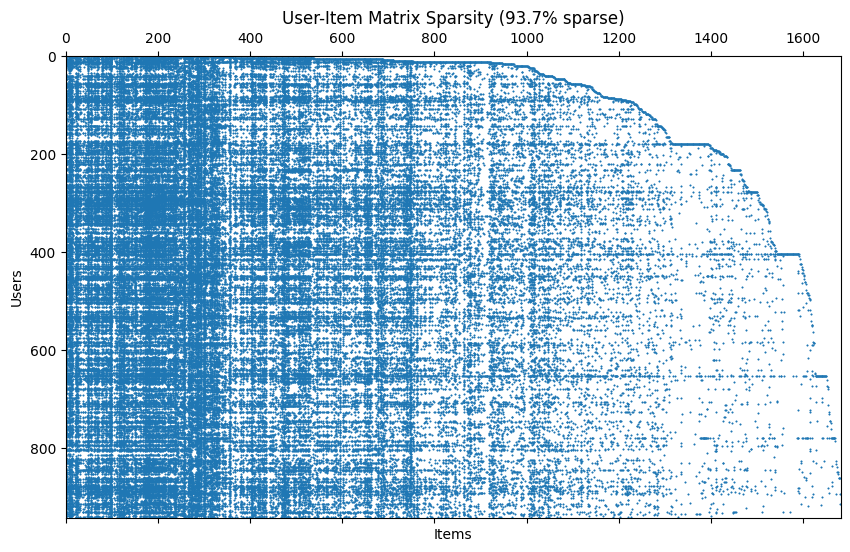

In [91]:
plt.figure(figsize=(10, 6))
plt.spy(user_item_matrix.notna(), markersize=0.5, aspect='auto')
plt.xlabel("Items")
plt.ylabel("Users")
plt.title(f"User-Item Matrix Sparsity ({sparsity:.1%} sparse)")
plt.show()

From this we can see that the data is very sparse meaning, few users have rated few movies, with a sparsity percentage of 93.7%